In [6]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

In [3]:
# Step 1: create highly overlapping data
np.random.seed(42)
cluster1 = np.random.randn(100, 2) * 1.5 + [4, 4]
cluster2 = np.random.randn(100, 2) * 1.5 + [4.5, 4.5]
X = np.vstack([cluster1, cluster2])

In [4]:
# Step 2: Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)
labels = gmm.predict(X)
means = gmm.means_
covariances = gmm.covariances_

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [5]:
# Step 3: Function to draw ellipse
def draw_ellipse(mean, covar, ax, **kwargs):
    U, s, _ = np.linalg.svd(covar)
    angle = np.degrees(np.arctan2(U[1,0], U[0,0]))
    width, height = 2 * np.sqrt(s)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

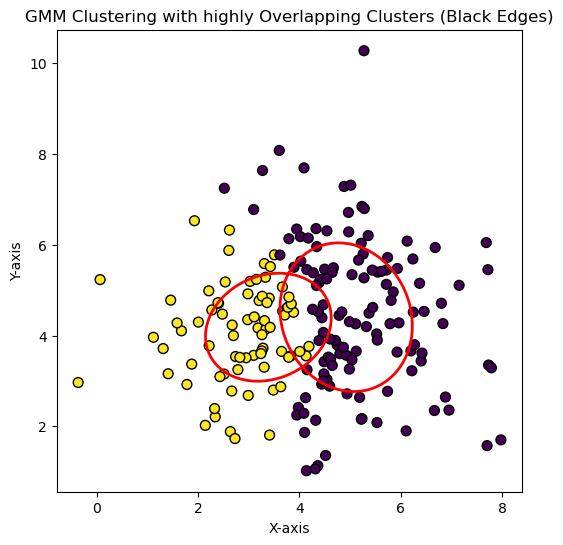

In [9]:
# Step 4: Plot points and ellipses with black edges
plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0], X[:,1],
    c=labels,
    cmap='viridis',
    s=50,
    zorder=2,
    edgecolors='k' # Black edge around points
)
ax = plt.gca()

for mean, covar in zip(means, covariances):
    draw_ellipse(mean, covar, ax, edgecolor='red', fc='None', lw=2, zorder=3)

plt.title("GMM Clustering with highly Overlapping Clusters (Black Edges)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()
